# Exploratory Data Analysis
## Melbourne Property Prices & Student Populations

In [30]:
# ===== 1. Imports =====
import pandas as pd
import matplotlib.pyplot as plt
import os

In [31]:
# ===== 2. Load data correctly=====
df = pd.read_csv("data/clean/cleaned_abs_suburbs.csv")
print("DATA PREVIEW:")
print(df.head())


DATA PREVIEW:
      suburb  total_persons  australian_citizens  non_citizens  \
0  Caulfield           5748                 4800           948   
1  Frankston          18801                16956          1845   
2  Doncaster          24814                18111          6703   
3   Werribee          50027                38806         11221   
4    Clayton          18988                 8565         10423   

   university_count  student_share  non_citizen_share  intl_student_proxy  \
0               418       0.072721           0.164927            0.011994   
1               691       0.036753           0.098133            0.003607   
2              1689       0.068066           0.270130            0.018387   
3              1818       0.036340           0.224299            0.008151   
4              4841       0.254950           0.548926            0.139949   

   median_weekly_rent  
0                 475  
1                 356  
2                 450  
3                 330  
4     

In [32]:
# ===== 3. Ensure columns are numeric =====
df["median_weekly_rent"] = pd.to_numeric(df["median_weekly_rent"], errors="coerce")
df["intl_student_proxy"] = pd.to_numeric(df["intl_student_proxy"], errors="coerce")

print("\nMISSING VALUES:")
print(df[["median_weekly_rent", "intl_student_proxy"]].isna().sum())



MISSING VALUES:
median_weekly_rent    0
intl_student_proxy    0
dtype: int64


In [33]:
# Drop missing values if any
df = df.dropna(subset=["median_weekly_rent", "intl_student_proxy"])

In [34]:

# ===== 4. Create outputs folder =====
os.makedirs("outputs/figures", exist_ok=True)


## Data Overview

The dataset contains 8 Melbourne suburbs with the following key variables:

- **median_weekly_rent** (AUD): Outcome variable representing rental prices
- **intl_student_proxy**: Proxy for international student concentration, calculated as:
  
  International Student Proxy = University Student Share × Non-Citizen Share

### Key Observations:
- Rent ranges from approximately **$330 to $475 per week**
- The student proxy ranges from **~0.003 to ~0.14**
- No missing values remain after cleaning

### Interpretation:
The data shows meaningful variation in both rent and student concentration, making it suitable for exploratory analysis. The cleaning process successfully removed missing values and ensured numeric formatting.




In [35]:
print("\nSUMMARY STATISTICS:")
print(df.describe())


SUMMARY STATISTICS:
       total_persons  australian_citizens  non_citizens  university_count  \
count       8.000000             8.000000      8.000000          8.000000   
mean    19517.125000         14310.875000   5206.250000       2231.500000   
std     13818.838647         11060.470714   4222.209839       1775.625363   
min      5748.000000          4800.000000    948.000000        418.000000   
25%     12629.500000          7770.000000   1724.750000        810.250000   
50%     17428.000000         10932.000000   4307.500000       1753.500000   
75%     20444.500000         17244.750000   8031.250000       3205.250000   
max     50027.000000         38806.000000  11221.000000       4885.000000   

       student_share  non_citizen_share  intl_student_proxy  \
count       8.000000           8.000000            8.000000   
mean        0.149579           0.264212            0.052536   
std         0.134984           0.161956            0.060965   
min         0.036340           0.

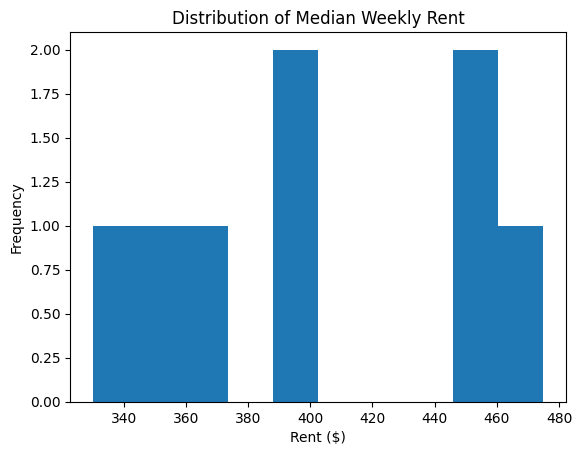

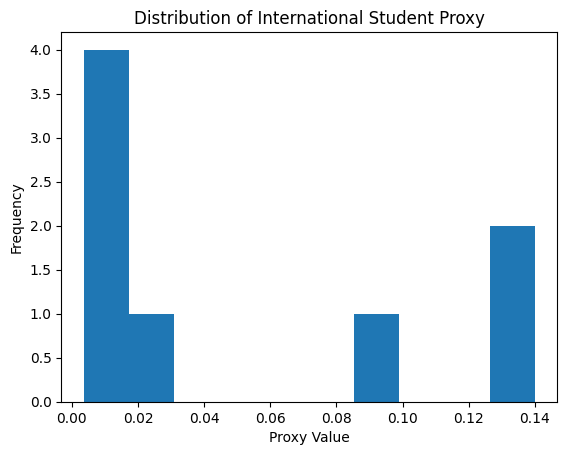

In [36]:
os.makedirs("outputs/figures", exist_ok=True)

# Histogram of rent
plt.figure()
plt.hist(df["median_weekly_rent"])
plt.title("Distribution of Median Weekly Rent")
plt.xlabel("Rent ($)")
plt.ylabel("Frequency")
plt.savefig("outputs/figures/hist_rent.png")
plt.show()

# Histogram of student proxy
plt.figure()
plt.hist(df["intl_student_proxy"])
plt.title("Distribution of International Student Proxy")
plt.xlabel("Proxy Value")
plt.ylabel("Frequency")
plt.savefig("outputs/figures/hist_proxy.png")
plt.show()

## Distribution Analysis

- Rental prices are moderately spread, with most suburbs clustered between $350 and $450.
- The international student proxy is skewed, with most suburbs having relatively low values.

### Interpretation:
This suggests that only a few suburbs have high concentrations of international students, while most have relatively low exposure.

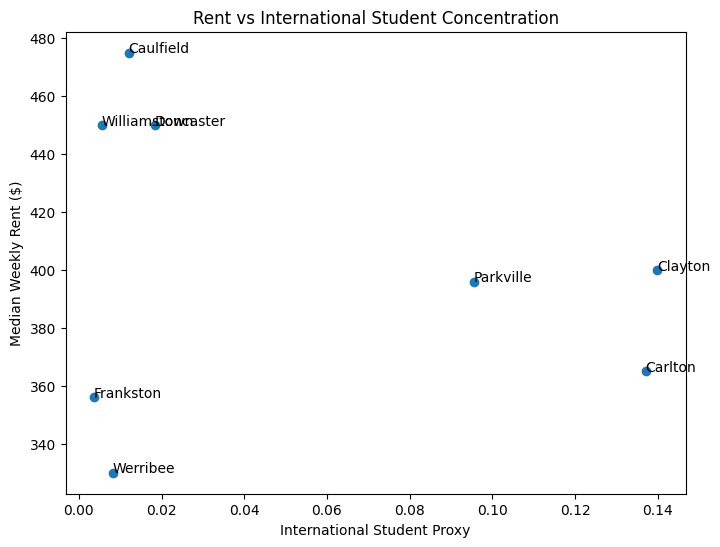

In [37]:
# ===== 5. Scatterplot =====
plt.figure(figsize=(8,6))
plt.scatter(df["intl_student_proxy"], df["median_weekly_rent"])

for i, row in df.iterrows():
    plt.text(row["intl_student_proxy"], row["median_weekly_rent"], row["suburb"])

plt.xlabel("International Student Proxy")
plt.ylabel("Median Weekly Rent ($)")
plt.title("Rent vs International Student Concentration")

plt.savefig("outputs/figures/scatterplot.png", dpi=300, bbox_inches="tight")
plt.show()

## Relationship Between Rent and Student Concentration

The scatter plot does not show a clear positive relationship between international student concentration and rental prices.

- Suburbs with high student proxy values (e.g. Clayton, Carlton) do not consistently have higher rents.
- Some low-proxy suburbs (e.g. Doncaster, Williamstown) have comparable or higher rents.

### Interpretation:
There is **no strong first-order relationship** between international student concentration and rent in this dataset.

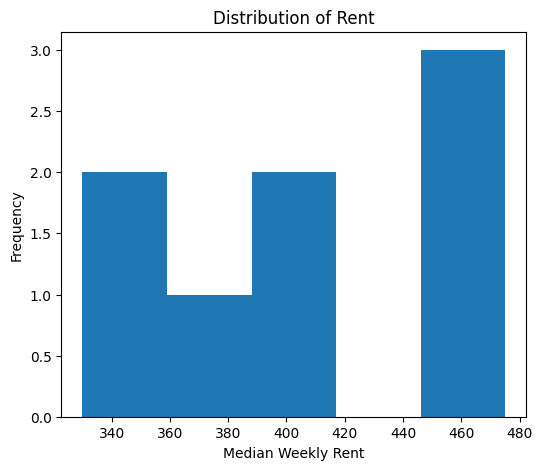

In [39]:
# ===== 7. Histogram =====
plt.figure(figsize=(6,5))
plt.hist(df["median_weekly_rent"], bins=5)

plt.xlabel("Median Weekly Rent")
plt.ylabel("Frequency")
plt.title("Distribution of Rent")

plt.savefig("outputs/figures/histogram.png", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
# ===== 8. Correlation =====
corr = df["intl_student_proxy"].corr(df["median_weekly_rent"])
print("\nCORRELATION:", corr)


CORRELATION: -0.2255551580901404


In [41]:
median_proxy = df["intl_student_proxy"].median()

high = df[df["intl_student_proxy"] > median_proxy]
low = df[df["intl_student_proxy"] <= median_proxy]

print("Average rent (high proxy):", high["median_weekly_rent"].mean())
print("Average rent (low proxy):", low["median_weekly_rent"].mean())

Average rent (high proxy): 402.75
Average rent (low proxy): 402.75


## High vs Low Student Concentration Comparison

Suburbs were divided into high and low student concentration groups using the median proxy.

### Findings:
- The average rent in both groups is approximately the same.

### Interpretation:
This suggests that international student concentration does not significantly affect rental prices in this sample.

<Figure size 600x500 with 0 Axes>

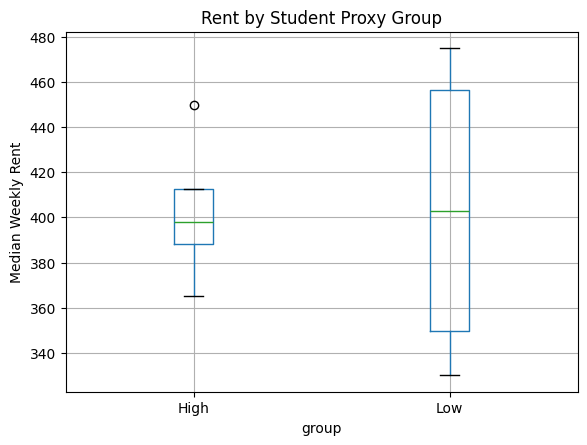

In [38]:

# ===== 6. Boxplot (High vs Low groups) =====
median_proxy = df["intl_student_proxy"].median()

df["group"] = df["intl_student_proxy"].apply(
    lambda x: "High" if x > median_proxy else "Low"
)

plt.figure(figsize=(6,5))
df.boxplot(column="median_weekly_rent", by="group")

plt.title("Rent by Student Proxy Group")
plt.suptitle("")
plt.ylabel("Median Weekly Rent")

plt.savefig("outputs/figures/boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

## Modelling Considerations

Several factors may affect the interpretation of results:

- **Small sample size (n=8)** limits statistical reliability
- Potential **omitted variables**:
  - distance to CBD
  - transport access
  - housing type
- The relationship may be **non-linear**
- No evidence of Simpson’s Paradox, but subgroup effects could exist with more data

### Implication:
A more comprehensive model with additional variables would be required for stronger conclusions.

## Key Takeaways

- There is **no strong correlation** between international student concentration and rental prices.
- Rent differences are likely driven by other structural factors.
- The proxy variable provides some variation but is **not a strong predictor on its own**.
- Given the limited variation and small sample size, no transformations were applied. However, with a larger dataset, log transformations or scaling could be considered to address skewness and improve interpretability.


### First-Order Effect

A first-order effect would imply a clear directional relationship between international student concentration and rental prices.

The exploratory analysis finds no evidence of a strong first-order effect, as increases in the international student proxy are not consistently associated with increases in rental prices. The scatterplot appears relatively flat, and the correlation coefficient is close to zero.

This suggests that any potential relationship is weak and likely overshadowed by other determinants of rental prices.


### Overall Conclusion:
International student concentration alone does not appear to significantly explain differences in rental prices across the selected Melbourne suburbs.